In [10]:
!pip install pandas matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 96.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


# Chargement du modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("./best_resnet18_model.pth", map_location=device))
model.eval().to(device)

# Transform
transform = transforms.Compose([
    transforms.Resize((700, 700)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Chargement et filtrage du CSV
df = pd.read_csv("./VinDr/breast-level_annotations.csv")
df = df[df["view_position"] == "MLO"]
df = df[df["breast_birads"].isin(["BI-RADS 1", "BI-RADS 2", "BI-RADS 3", "BI-RADS 4", "BI-RADS 5"])]
df["label"] = (df["breast_birads"] == "BI-RADS 1").astype(int)

destination_transformee = "./VinDr_transforme/"

In [12]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu130
13.0
False


In [13]:
# Inférence sur VinDr transformé
all_predictions = []
all_labels = []
all_probabilities = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    # Détermination de la classe
    classe = "normal" if row["label"] == 1 else "cancer_benign"
    img_path = os.path.join(destination_transformee, classe, row["image_id"] + ".png")
    
    if not os.path.exists(img_path):
        continue
    
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        _, pred = torch.max(outputs, 1)
        all_predictions.append(pred.item())
        all_labels.append(row["label"])
        all_probabilities.append(probabilities[0][0].item())

predictions_np = np.array(all_predictions)
labels_np = np.array(all_labels)
probabilities_np = np.array(all_probabilities)

accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')

100%|██████████| 9999/9999 [27:22<00:00,  6.09it/s]  

Test_Accuracy : 67.0267%


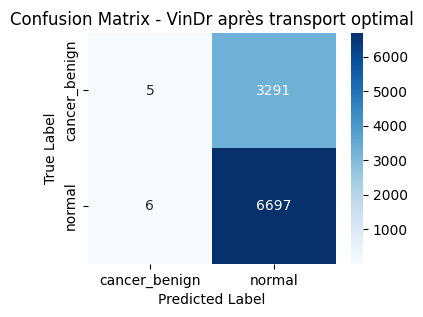

Rapport de classification :
               precision    recall  f1-score   support

cancer_benign       0.45      0.00      0.00      3296
       normal       0.67      1.00      0.80      6703

     accuracy                           0.67      9999
    macro avg       0.56      0.50      0.40      9999
 weighted avg       0.60      0.67      0.54      9999



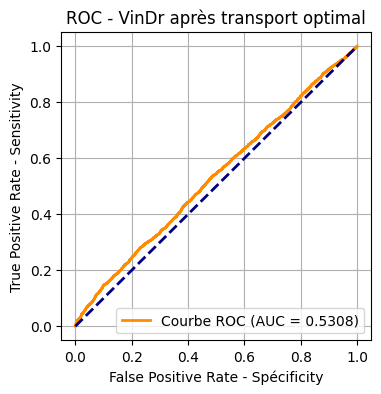

In [14]:
# Matrice de confusion
class_names = ['cancer_benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - VinDr après transport optimal')
plt.show()

# Rapport de classification
report = classification_report(labels_np, predictions_np, target_names=class_names)
print("Rapport de classification :")
print(report)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate - Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('ROC - VinDr après transport optimal')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()